In [ ]:
import os
import glob

import healpy as hp
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import cosmoglobe as cg
import cmocean.cm as cm
import cmasher as cmr

from astropy.io import fits

# Sets style for all plots
plt.rcParams['font.size'] = '16'
plt.rcParams['savefig.facecolor']='white'
plt.rcParams['axes.titlepad'] = 18
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif"
})
plt.rcParams["errorbar.capsize"] = 5

# Utility functions
def get_akari_bands(chains):
    """Extracts the specific AKARI bands of the run"""
    bands = sorted(filename.split('_')[-1].replace('.txt', '')
                   for filename in os.listdir(chains)
                   if filename.startswith('filelist_AKARI_') and filename.endswith('.txt')
                   )

    return bands

def get_nside(fits_file):
    """Extracts the NSIDE value from the header of a FITS file."""  
    with fits.open(fits_file) as hdul:
        for hdu in hdul:
            if 'NSIDE' in hdu.header:
                return hdu.header['NSIDE']

    raise KeyError(f"No NSIDE keyword found in {fits_file}")

# Plotting class for AKARI maps
class AKARIMapPlotter:

    DEFAULT_MAP_CONFIGS = {
        'map':   {'vmin': -30, 'vmax': 30, 'toggle_last_only': False},
        'ncorr': {'vmin': -10, 'vmax': 10, 'toggle_last_only': True},
        'res':   {'vmin': -1,  'vmax': 1,  'toggle_last_only': True},
        'rms':   {'vmin': 0,   'vmax': 2,  'toggle_last_only': True},
    }

    def __init__(self, out_dir, chains_dir, bands, nside):
        self.out_dir = out_dir
        self.chains_dir = chains_dir
        self.bands = bands
        self.nside = nside
        self.resol = f'n{nside}'

    @classmethod
    def from_chains(cls, chains_dir, out_dir):

        bands = get_akari_bands(chains_dir)

        nside = get_nside(os.path.join(chains_dir,f'tod_AKARI_{bands[0]}_inst_c0001_k000001.fits'))

        print('bands:', bands)
        print('nside:', nside)

        return cls(
            out_dir=out_dir,
            chains_dir=chains_dir,
            bands=bands,
            nside=nside,
        )


    def _select_files(self, file_list, toggle_last_only):
        """reduces the filelist to max 11 maps (first 10 iterations + final iteration) if toggle_last_only is False, otherwise only the final iteration"""
        if len(file_list) == 0:
            return []

        if toggle_last_only:
            return [file_list[-1]]

        if len(file_list) <= 10:
            return file_list

        return file_list[:10] + [file_list[-1]]

    def _plot_single_map(self, map_data, title, outfile, vmin, vmax, cmap):
        """Helper function to plot a single map with the given parameters and save it to the specified output file."""

        fig, ax = plt.subplots(figsize=(8, 5))
        plt.axes(ax)

        hp.mollview(
            map_data,
            title=title,
            min=vmin,
            max=vmax,
            cmap=cmap,
            hold=True,
            cbar=False,
        )

        hp.graticule(dmer=360, dpar=360, alpha=0)

        divider = make_axes_locatable(ax)
        cax = divider.append_axes("bottom", size="5%", pad="1%")

        sm = mpl.cm.ScalarMappable(
            cmap=cmap,
            norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax)
        )
        sm.set_array([])

        fig.colorbar(
            sm,
            cax=cax,
            orientation='horizontal',
            ticks=[vmin, vmax]
        )

        plt.savefig(outfile,
                    bbox_inches='tight',
                    dpi=300)

        plt.close()

    def plot_map_type(self, map_type, vmin, vmax, cmap, toggle_last_only=False, bands=None):
        """Generates maps of the specified type for each band and saves them to the output directory. If bands is None, it defaults to all bands in self.bands."""

        if bands is None:
            bands = self.bands

        for band in bands:
            print(f'generating {map_type} map for {band}')

            pattern = (f'{self.chains_dir}'f'tod_AKARI_{band}_{map_type}*')
            file_list = np.sort(glob.glob(pattern))

            selected_files = self._select_files(file_list,toggle_last_only)

            webpath = f'{self.out_dir}/{self.resol}/{band}/'
            os.makedirs(webpath, exist_ok=True)

            name_cut = 30 + len(band) + len(map_type)

            for filename in selected_files:
                if '.fits' not in filename:
                    continue

                map_data = hp.read_map(filename)

                title = filename[-name_cut:]
                outfile = f'{webpath}{title}.png'

                self._plot_single_map(map_data, title, outfile, vmin, vmax, cmap)

            print(f'{map_type} maps for {band} saved to {webpath}')

    def plot_band(self, band, map_type, vmin, vmax, cmap=cmr.fusion_r, toggle_last_only=True):
        """wrapper for single band plot"""
        self.plot_map_type(map_type=map_type, vmin=vmin, vmax=vmax, cmap=cmap, toggle_last_only=toggle_last_only, bands=[band])

    def plot_all(self, map_configs=None, cmap=cmr.fusion_r):
        """wrapper to plot all map types with their respective configurations"""
        if map_configs is None:
            map_configs = self.DEFAULT_MAP_CONFIGS

        for map_type, cfg in map_configs.items():

            self.plot_map_type(
                map_type=map_type,
                vmin=cfg['vmin'],
                vmax=cfg['vmax'],
                cmap=cmap,
                toggle_last_only=cfg['toggle_last_only'],
            )

    def plot_zoom_ins(self, fov_deg=2, reso_arcmin=0.02, vmin=0,vmax=10,cmap=cm.thermal,toggle_last_only=True,bands=None):

        if bands is None:
            bands = self.bands

        coords = [
            (121.2, -21.6),                   # Andromeda
            (96, 30),                         # NEP
            (315, -55),                       # Southern Hole
            # (259.9663579319, 38.0740906071),  # U-Hydrae
        ]

        xsize = int(fov_deg * 60 / reso_arcmin)

        map_type = 'map'

        for band in bands:
            print(f'generating zoom-in {map_type} map for {band}')

            pattern = (f'{self.chains_dir}tod_AKARI_{band}_{map_type}*')

            file_list = np.sort(glob.glob(pattern))
            selected_files = self._select_files(file_list,toggle_last_only)

            webpath = f'{self.out_dir}/{self.resol}/{band}/'
            os.makedirs(webpath, exist_ok=True)

            name_cut = 30 + len(band) + len(map_type)

            for filename in selected_files:
                fitsmap = hp.read_map(filename)
                for coord in coords:

                    hp.gnomview(
                        fitsmap,
                        rot=coord,
                        coord='G',
                        title=filename[-name_cut:],
                        min=vmin,
                        max=vmax,
                        cmap=cmap,
                        xsize=xsize,
                        reso=reso_arcmin,
                    )

                    outfile = (f'{webpath}gnomview_{filename[-name_cut:]}_{coord[0]}_{coord[1]}.png')

                    plt.savefig(outfile,
                                bbox_inches='tight',
                                dpi=300)
                    plt.close()

            print(f'done for {band}')

    def plot_cls(self,bands=None,map_type='map',outfile='cls.png'):
        """Compute and plot power spectra of the final map iteration."""

        if bands is None:
            bands = self.bands

        cls = []

        for band in bands:
            print(f'computing Cl for {band}')

            pattern = (f'{self.chains_dir}tod_AKARI_{band}_{map_type}*')

            file_list = np.sort(glob.glob(pattern))
            if len(file_list) == 0:
                print(f'No files found for {band}')
                continue

            map_data = hp.read_map(file_list[-1],memmap=True)

            cls.append(hp.anafast(map_data))

        fig, axs = plt.subplots(
            len(bands),
            1,
            sharex=True,
            figsize=(6, 2.5*len(bands)),
            gridspec_kw={'hspace': 0})

        if len(bands) == 1:
            axs = [axs]

        for ax, band, cl_band in zip(axs, bands, cls):
            ax.loglog(cl_band,label=f'{band} $\\mu$m',c='k')
            ax.legend(frameon=False)
            axs[-1].set_xlabel(r'Multipole $\ell$')

        fig.supylabel(r'Power spectrum, $C_\ell$ (MJy$^2$/sr)',x=-0.02)

        webpath = f'{self.out_dir}/{self.resol}/'
        os.makedirs(webpath, exist_ok=True)

        plt.savefig(
            f'{webpath}{outfile}',
            bbox_inches='tight',
            dpi=300)

        plt.close()

        print(f'Cl plot saved to {webpath}{outfile}')




In [ ]:
def main():
    parent_dir = "/mn/stornext/u3/katrinag/data_path/work_comm3/akari/all_bands/n8192/"
    chains_dir = os.path.join(parent_dir, "chains_akari_all_v01/")
    out_dir = "/mn/stornext/d16/www_cmb/katrinag/akari_all_bands/"

    # Defines the plotter object
    plotter = AKARIMapPlotter.from_chains(chains_dir=chains_dir, out_dir=out_dir)


    ### FOR CREATING ALL THE DEFAULT OUTPUTS -- UNCOMMENT TO RUN
    MAP_CONFIGS = {
        'map':   {'vmin': -30, 'vmax': 30, 'toggle_last_only': False},
        'ncorr': {'vmin': -10, 'vmax': 10, 'toggle_last_only': True},
        'res':   {'vmin': -1, 'vmax': 1, 'toggle_last_only': True},
        'rms':   {'vmin': 0, 'vmax': 2, 'toggle_last_only': True},
    }
    # plotter.plot_all(map_configs=MAP_CONFIGS)

    ### FOR CREATING A SINGLE MAP TYPE WITH CUSTOM CONFIGURATION -- UNCOMMENT TO RUN
    # plotter.plot_band(band='160', map_type='rms', vmin=0, vmax=10, cmap=cmr.fusion_r, toggle_last_only=True)

    ### FOR CREATING ZOOM-IN PLOTS -- UNCOMMENT TO RUN
    # plotter.plot_zoom_ins(vmin=-27, vmax=102)

    ### FOR CREATING ZOOM-IN PLOTS FOR A SINGLE BAND -- UNCOMMENT TO RUN
    # plotter.plot_zoom_ins(bands=['160'], fov_deg=2, reso_arcmin=0.02, vmin=-27, vmax=102)

    ### FOR PLOTTING POWER SPECTRA -- UNCOMMENT TO RUN
    plotter.plot_cls()

if __name__ == "__main__":
    main()

bands: ['065', '090', '140', '160']
nside: 8192
computing Cl for 065


In [ ]:
def zoom_ins(vmin=0, vmax=10, cmap=cm.thermal_r, toggle_last_only=True, bands=None):

    toggle_gnomview = True
    coords = [
            (121, -22),  # Andromeda,
            (96, 30),    # North Ecliptic Pole (NEP)
            (315,  -55), # Southern Hole
            (259.9663579319, 38.0740906071), # U-Hydrae, 259.9663579319 +38.0740906071 
            ] 
    # iter_num = 9 # the start from 1

    FOV_deg = 0.5
    reso_arcmin = 0.2
    xsize = int(FOV_deg * 60 / reso_arcmin)
    map_type='map'

    for band in bands:
        print(f'generating zoom-in {map_type} map for {band}')
        pattern = (f'{self.chains_dir}'f'tod_AKARI_{band}_{map_type}*')
        file_list = np.sort(glob.glob(pattern))
        selected_files = self._select_files(file_list,toggle_last_only)

        webpath = f'{self.out_dir}/{self.resol}/{band}/'
        os.makedirs(webpath, exist_ok=True)


        fitsmap = hp.read_map(selected_files) 

        name_cut = 30+len(band)+len(type)

        for coord in coords:
            hp.gnomview(fitsmap,
                        rot=coord,
                        coord='G',
                        title=selected_files[-name_cut:],
                        min=vmin,
                        max=vmax,
                        cmap=cmap,
                        xsize=xsize,#200,#1500, #800, #200,
                        reso=reso_arcmin,#0.2, #1.5,
                        )
            plt.savefig(webpath+'gnomview_'+selected_files[-name_cut:]+'_'+str(coord[0])+'_'+str(coord[1])+'.png', 
                        bbox_inches='tight', 
                        dpi=300)
            # plt.close()

        print(f'done for {band}')

# Plot fits file

In [3]:
# gnomview single iteration
bands = ['N60', 'WIDE-S', 'WIDE-L']#, ['N60', 'N160', 'WIDE-S', 'WIDE-L']
type = 'map' #['map', 'ncorr', 'res', 'rms']
version = 'v00'

toggle_gnomview = True
coords = [
          (121.2, -21.6),  # Andromeda,
          (96, 30),    # North Ecliptic Pole (NEP)
          (315,  -55), # Southern Hole
          (259.9663579319, 38.0740906071), # U-Hydrae, 259.9663579319 +38.0740906071 
          ] 
iter_num = 9 # the start from 1

cmap = cm.thermal_r 


FOV_deg = 0.5
reso_arcmin = 0.2
xsize = int(FOV_deg * 60 / reso_arcmin)

vmin, vmax = 0, 10

for band in bands:
    # band = 'N60'
    file_path = parentpath + 'chains_akari_'+band.lower()+'_'+version+'/' # chains_akari_n60_v00
    # file_name = 'tod_AKARI_N60_map_c0001_k000010.fits' #'zodi_map_approx_test'
    # fits_file = hp.read_map(file_path + file_name)# + '.fits') 
    file_list = np.sort(glob.glob(file_path+'tod_AKARI_'+band+'_'+type+'*'))
    fitsmap = hp.read_map(file_list[iter_num]) 
    webpath = '/mn/stornext/d16/www_cmb/katrinag/akari_all_dets-narrow/'+band+'/'

    name_cut = 30+len(band)+len(type)

    for coord in coords:
        hp.gnomview(fitsmap,
                    rot=coord,
                    coord='G',
                    title=file_list[iter_num][-name_cut:],
                    min=vmin,
                    max=vmax,
                    cmap=cmap,
                    xsize=xsize,#200,#1500, #800, #200,
                    reso=reso_arcmin,#0.2, #1.5,
                    )
        plt.savefig(webpath+'gnomview_'+file_list[iter_num][-name_cut:]+'_'+str(coord[0])+'_'+str(coord[1])+'.png', 
                    bbox_inches='tight', 
                    dpi=300)
        # plt.close()

    print(f'done for {band}')

NameError: name 'parentpath' is not defined

# Plots for testing

done with ncorr for gain for N60
done with ncorr for ncorr-10 for N60


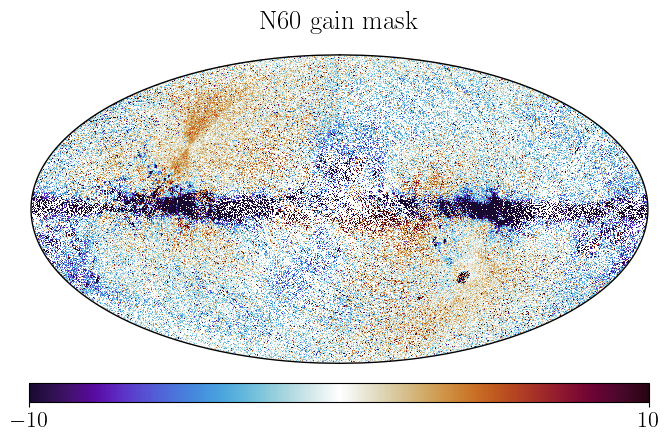

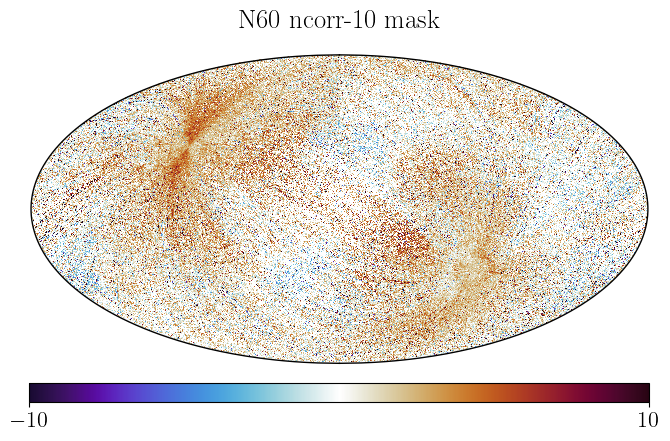

In [30]:
# Single iteration maps
bands = ['N60']#, 'N160', 'WIDE-S', 'WIDE-L']
type = 'ncorr' #['map', 'ncorr', 'res', 'rms']
iter_num = 9 # the start from 1, so 9=10

bitmasks = ['gain', 'ncorr-10'] 

# cmap = cm.thermal_r 
# cmap = cm.thermal
# cmap = cm.balance
# cmap = cmr.dusk
# cma = cm.tarn
# cmap = "Spectral_r"
cmap = cmr.fusion_r
# cmap = "Spectral_r"
# cmap = "seismic"
# cmap = "managua_r"
# cmap = "jet"
# cmap = cm.deep_r
# cmap = cm.solar

for band in bands:
    for bitmask in bitmasks:
        # file_path = parentpath + 'chains_akari_'+band.lower()+'/' #'/mn/stornext/d5/data/duncanwa/DIRBE/'
        file_path = parentpath + 'chains_akari_'+band.lower()+'_det17_'+bitmask+'/' 


        # file_name = 'tod_AKARI_N60_map_c0001_k000010.fits' #'zodi_map_approx_test'
        # fits_file = hp.read_map(file_path + file_name)# + '.fits') 
        file_list = np.sort(glob.glob(file_path+'tod_AKARI_'+band+'_'+type+'*'))
        fitsmap = hp.read_map(file_list[iter_num]) # change this.
        # webpath = '/mn/stornext/d16/www_cmb/katrinag/akari_all_dets/'+band+'/'
        webpath = '/mn/stornext/d16/www_cmb/katrinag/akari_ncorr_bitmask/'


        if type == 'res':
            vmin, vmax = -1, 1
        elif type == 'rms':
            vmin, vmax = 0, 2
        elif type == 'ncorr':
            vmin, vmax = -10, 10
        else:
            vmin, vmax = -30, 30
            # vmin,vmax=-5,5
            # vmin, vmax = 0, 5

        name_cut = 30+len(band)+len(type)

        fig, (ax1) = plt.subplots(ncols=1, figsize=(8,5))
        plt.axes(ax1)

        hp.mollview(
                    fitsmap,
                    # np.arcsinh((fitsmap/5)/5),
                    # title=file_list[iter_num][-name_cut:], 
                    title=band+' '+bitmask+' mask',
                    min=vmin, 
                    max=vmax, 
                    cmap=cmap,
                    hold=True,
                    cbar=False,
                    ) 

        # Border around the plot -- the white background looks weird otherwise!
        hp.graticule(dmer=360, dpar=360, alpha=0)

        divider = make_axes_locatable(ax1)
        cax = divider.append_axes("bottom", size="5%", pad="1%")

        sm = mpl.cm.ScalarMappable(
            cmap=cmap,
            norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax)
        )
        sm.set_array([])

        cbar = fig.colorbar(sm,
                            cax=cax,
                            orientation='horizontal',
                            ticks=[vmin,vmax],
                            )


        plt.savefig(webpath+bitmask+'_'+file_list[iter_num][-name_cut:]+'.png', 
                    bbox_inches='tight', 
                    # transparent=False, 
                    dpi=300,#fig.dpi,
                    # facecolor='white')
                    )
        # plt.close()



        print(f'done with {type} for {bitmask} for {band}')

done with map for 65
done with map for 160
done with map for WideS
done with map for WideL


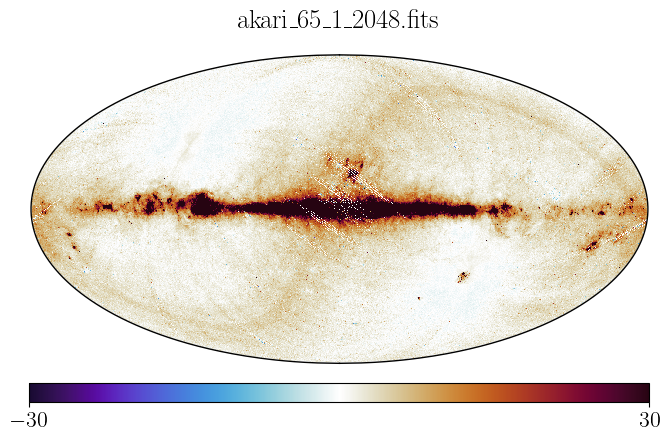

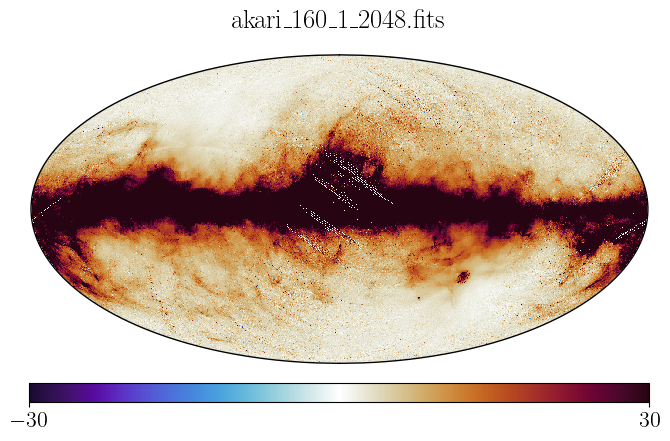

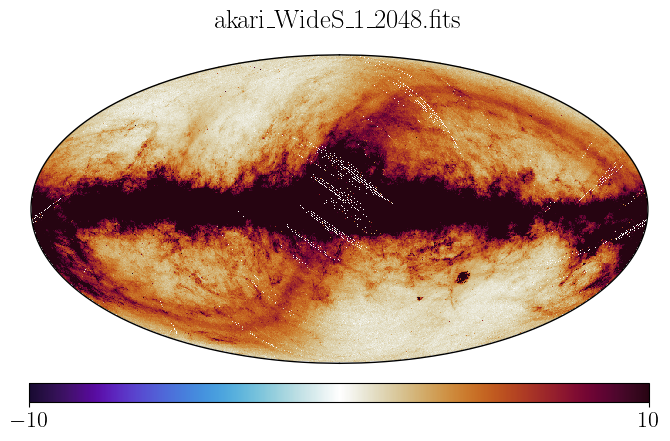

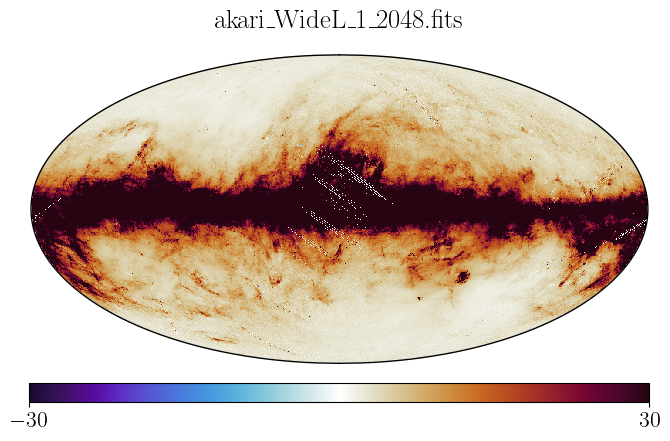

In [ ]:
# Official maps
official_path = '/mn/stornext/d23/cmbco/globe/akari/maps/'
orig_bands = ['65', '160', 'WideS', 'WideL']
bands = ['N60', 'N160', 'WIDE-S', 'WIDE-L']
type = 'map' #['map', 'ncorr', 'res', 'rms']

# cmap = cm.thermal_r 
# cmap = cm.thermal
# cmap = cm.balance
# cmap = cmr.dusk
# cma = cm.tarn
# cmap = "Spectral_r"
cmap = cmr.fusion_r
# cmap = "Spectral_r"
# cmap = "seismic"
# cmap = "managua_r"
# cmap = "jet"
# cmap = cm.deep_r

for band, webband in zip(orig_bands, bands):
    # file_name = 'tod_AKARI_N60_map_c0001_k000010.fits' #'zodi_map_approx_test'
    # fits_file = hp.read_map(file_path + file_name)# + '.fits') 
    file_list = official_path+'akari_'+band+'_1_2048.fits' #akari_160_1_2048.fits 
    fitsmap = hp.read_map(file_list) # change this.
    webpath = '/mn/stornext/d16/www_cmb/katrinag/akari_all_dets-narrow/'+webband+'/'


    if band == '65':
        # vmin, vmax = -7, 7
        vmin, vmax = -30, 30
        # vmin, vmax = 0, 5
    elif band == 'WideS':
        vmin, vmax = -10, 10
    else:
        vmin, vmax = -30, 30

    name_cut = 18+len(band)

    fig, (ax1) = plt.subplots(ncols=1, figsize=(8,5))
    plt.axes(ax1)

    hp.mollview(
                fitsmap,
                # np.arcsinh((fitsmap)/5),
                title=file_list[-name_cut:], 
                min=vmin, 
                max=vmax, 
                cmap=cmap,
                hold=True,
                cbar=False,
                ) 

    # Border around the plot -- the white background looks weird otherwise!
    hp.graticule(dmer=360, dpar=360, alpha=0)

    divider = make_axes_locatable(ax1)
    cax = divider.append_axes("bottom", size="5%", pad="1%")

    sm = mpl.cm.ScalarMappable(
        cmap=cmap,
        norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    )
    sm.set_array([])

    cbar = fig.colorbar(sm,
                        cax=cax,
                        orientation='horizontal',
                        ticks=[vmin,vmax],
                        )

    plt.savefig(webpath+'/official_'+file_list[-name_cut:]+'.png', 
                bbox_inches='tight', 
                # transparent=False, 
                dpi=300,#fig.dpi,
                # facecolor='white')
                )
    # plt.close()



    print(f'done with {type} for {band}')

# Plots for presentation

done with map for N60


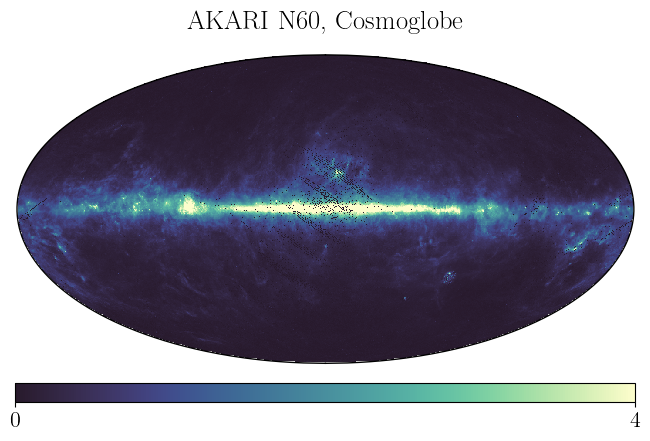

In [ ]:
# Single iteration maps
bands = ['N60']#, 'N160', 'WIDE-S', 'WIDE-L']
type = 'map' #['map', 'ncorr', 'res', 'rms']
iter_num = 9 # the start from 1, so 9=10

# cmap = cm.thermal_r 
# cmap = cm.thermal
# cmap = cm.balance
# cmap = cmr.dusk
# cma = cm.tarn
# cmap = "Spectral_r"
# cmap = cmr.fusion_r
# cmap = "Spectral_r"
# cmap = "seismic"
# cmap = "managua_r"
# cmap = "jet"
cmap = cm.deep_r
# cmap = cm.solar


webpath = '/mn/stornext/d16/www_cmb/katrinag/akari_all_dets-narrow/presentation/'
for band in bands:
    file_path = parentpath + 'chains_akari_'+band.lower()+'/' #'/mn/stornext/d5/data/duncanwa/DIRBE/'
    # file_name = 'tod_AKARI_N60_map_c0001_k000010.fits' #'zodi_map_approx_test'
    # fits_file = hp.read_map(file_path + file_name)# + '.fits') 
    file_list = np.sort(glob.glob(file_path+'tod_AKARI_'+band+'_'+type+'*'))
    fitsmap = hp.read_map(file_list[iter_num]) # change this.

    if type == 'res':
        vmin, vmax = -1, 1
    elif type == 'rms':
        vmin, vmax = 0, 4
    else:
        # vmin, vmax = -30, 30
        # vmin,vmax=-5,5
        vmin, vmax = 0, 4

    name_cut = 30+len(band)+len(type)

    fig, (ax1) = plt.subplots(ncols=1, figsize=(8,5))
    plt.axes(ax1)

    hp.mollview(
                # fitsmap/5,
                np.arcsinh((fitsmap/5)/5),
                title='AKARI '+band+', Cosmoglobe',#file_list[iter_num][-name_cut:], 
                min=vmin, 
                max=vmax, 
                cmap=cmap,
                hold=True,
                cbar=False,
                ) 

    # Border around the plot -- the white background looks weird otherwise!
    hp.graticule(dmer=360, dpar=360, alpha=0)

    divider = make_axes_locatable(ax1)
    cax = divider.append_axes("bottom", size="5%", pad="1%")

    sm = mpl.cm.ScalarMappable(
        cmap=cmap,
        norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    )
    sm.set_array([])

    cbar = fig.colorbar(sm,
                        cax=cax,
                        orientation='horizontal',
                        ticks=[vmin,vmax],
                        )


    plt.savefig(webpath+file_list[iter_num][-name_cut:]+'.png', 
                bbox_inches='tight', 
                # transparent=False, 
                dpi=300,#fig.dpi,
                # facecolor='white')
                )
    # plt.close()



    print(f'done with {type} for {band}')

done with map for 65


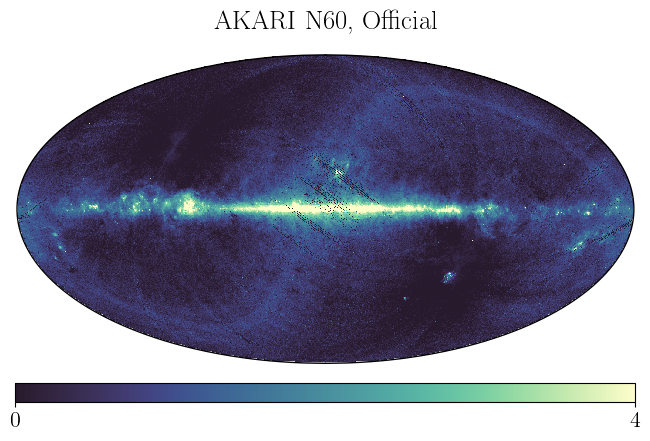

In [ ]:
# Official maps
official_path = '/mn/stornext/d23/cmbco/globe/akari/maps/'
orig_bands = ['65']#, '160', 'WideS', 'WideL']
bands = ['N60']#, 'N160', 'WIDE-S', 'WIDE-L']
type = 'map' #['map', 'ncorr', 'res', 'rms']

# cmap = cm.thermal_r 
# cmap = cm.thermal
# cmap = cm.balance
# cmap = cmr.dusk
# cma = cm.tarn
# cmap = "Spectral_r"
# cmap = cmr.fusion_r
# cmap = "Spectral_r"
# cmap = "seismic"
# cmap = "managua_r"
# cmap = "jet"
cmap = cm.deep_r
webpath = '/mn/stornext/d16/www_cmb/katrinag/akari_all_dets-narrow/presentation/'

for band, webband in zip(orig_bands, bands):
    # file_name = 'tod_AKARI_N60_map_c0001_k000010.fits' #'zodi_map_approx_test'
    # fits_file = hp.read_map(file_path + file_name)# + '.fits') 
    file_list = official_path+'akari_'+band+'_1_2048.fits' #akari_160_1_2048.fits 
    fitsmap = hp.read_map(file_list) # change this.

    if band == '65':
        # vmin, vmax = -7, 7
        # vmin, vmax = -30, 30
        vmin, vmax = 0, 4
    elif band == 'WideS':
        vmin, vmax = -10, 10
    else:
        vmin, vmax = -30, 30

    name_cut = 18+len(band)

    fig, (ax1) = plt.subplots(ncols=1, figsize=(8,5))
    plt.axes(ax1)

    hp.mollview(
                # fitsmap,
                np.arcsinh((fitsmap)/5),
                title='AKARI '+webband+', Official',#file_list[-name_cut:], 
                min=vmin, 
                max=vmax, 
                cmap=cmap,
                hold=True,
                cbar=False,
                ) 

    # Border around the plot -- the white background looks weird otherwise!
    hp.graticule(dmer=360, dpar=360, alpha=0)

    divider = make_axes_locatable(ax1)
    cax = divider.append_axes("bottom", size="5%", pad="1%")

    sm = mpl.cm.ScalarMappable(
        cmap=cmap,
        norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    )
    sm.set_array([])

    cbar = fig.colorbar(sm,
                        cax=cax,
                        orientation='horizontal',
                        ticks=[vmin,vmax],
                        )

    plt.savefig(webpath+'/official_'+file_list[-name_cut:]+'.png', 
                bbox_inches='tight', 
                # transparent=False, 
                dpi=300,#fig.dpi,
                # facecolor='white')
                )
    # plt.close()



    print(f'done with {type} for {band}')